# Hotel Price Analysis (2012–2016)

**Objective:** Analyze daily hotel pricing data to uncover seasonal patterns, 
identify outliers, and forecast prices for February 2022.

**Dataset:** Daily hotel prices from January 1, 2012 to January 16, 2016  
**Tools:** Python, Pandas, Matplotlib, Seaborn, Scipy, Prophet

In [1]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

# Plot styling — clean, professional look
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 0. Data Loading & Cleaning

In [2]:
def load_and_clean_data(filepath):
    """
    Loads the hotel price CSV, parses dates, sorts chronologically,
    and adds useful time-based columns for analysis.
    """
    df = pd.read_csv(filepath, parse_dates=['Date'])
    
    # Sort by date to ensure correct time order
    df = df.sort_values('Date').reset_index(drop=True)
    
    # Add helper columns we'll use throughout the analysis
    df['Year']       = df['Date'].dt.year
    df['Month']      = df['Date'].dt.month
    df['Month_Name'] = df['Date'].dt.strftime('%b')   # Jan, Feb, etc.
    df['Day']        = df['Date'].dt.day
    df['DayOfWeek']  = df['Date'].dt.dayofweek        # 0=Monday, 6=Sunday
    df['DayOfYear']  = df['Date'].dt.dayofyear
    
    return df

# Load the data — update path if needed
df = load_and_clean_data('data/Multi-Year Price Data (Aggregate).csv')

# Quick sanity check
print(f"Shape       : {df.shape}")
print(f"Date range  : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Years cover : {sorted(df['Year'].unique())}")
print(f"Missing vals: {df.isnull().sum().to_dict()}")
print(f"\nFirst 5 rows:")
df.head()

Shape       : (1476, 8)
Date range  : 2012-01-01 → 2016-01-16
Years cover : [np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016)]
Missing vals: {'Date': 0, 'Price': 0, 'Year': 0, 'Month': 0, 'Month_Name': 0, 'Day': 0, 'DayOfWeek': 0, 'DayOfYear': 0}

First 5 rows:


,Date,Price,Year,Month,Month_Name,Day,DayOfWeek,DayOfYear
0,2012-01-01,99,2012,1,Jan,1,6,1
1,2012-01-02,95,2012,1,Jan,2,0,2
2,2012-01-03,96,2012,1,Jan,3,1,3
3,2012-01-04,95,2012,1,Jan,4,2,4
4,2012-01-05,93,2012,1,Jan,5,3,5


In [3]:
def find_missing_dates(df):
    """
    Checks if any dates are missing from the full expected date range.
    Important to know before doing any time-series analysis.
    """
    full_range = pd.date_range(
        start=df['Date'].min(), 
        end=df['Date'].max(), 
        freq='D'
    )
    missing = full_range.difference(df['Date'])
    
    if len(missing) == 0:
        print("No missing dates found.")
    else:
        print(f"Found {len(missing)} missing date(s):")
        for d in missing:
            print(f"  → {d.date()}")
    
    return missing

missing_dates = find_missing_dates(df)

Found 1 missing date(s):
  → 2012-07-13


## Part 1: Year-over-Year Seasonal Patterns

To identify repeating annual patterns, we use two complementary visualizations:
1. **Multi-line chart** — one line per year, overlaid on the same axis (Jan–Dec)
2. **Monthly heatmap** — average price by month and year, making patterns immediately scannable

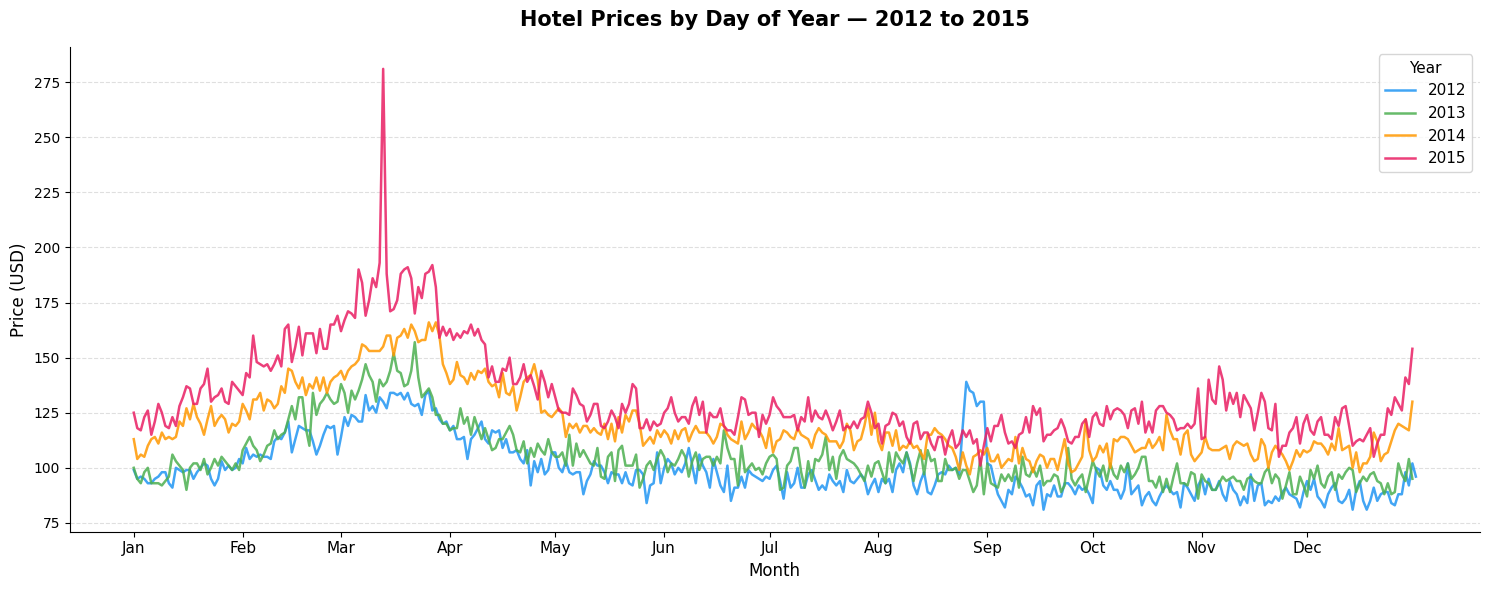

Chart saved.


In [4]:
def plot_yoy_overlay(df):
    """
    Overlays each year's daily prices on the same Jan-Dec axis.
    This makes seasonal patterns and year-over-year price growth immediately visible.
    """
    # Use only full years for a clean comparison (exclude partial 2016)
    full_years = [2012, 2013, 2014, 2015]
    colors     = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
    
    fig, ax = plt.subplots(figsize=(15, 6))
    
    for year, color in zip(full_years, colors):
        year_data = df[df['Year'] == year].copy()
        ax.plot(
            year_data['DayOfYear'],
            year_data['Price'],
            label=str(year),
            color=color,
            linewidth=1.8,
            alpha=0.85
        )
    
    # X-axis: show month names instead of day numbers
    month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']
    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_labels, fontsize=11)
    
    ax.set_title('Hotel Prices by Day of Year — 2012 to 2015',
                 fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Price (USD)', fontsize=12)
    ax.legend(title='Year', fontsize=11, title_fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.savefig('plots/part1_yoy_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart saved.")

# Create plots folder if it doesn't exist
import os
os.makedirs('plots', exist_ok=True)

plot_yoy_overlay(df)

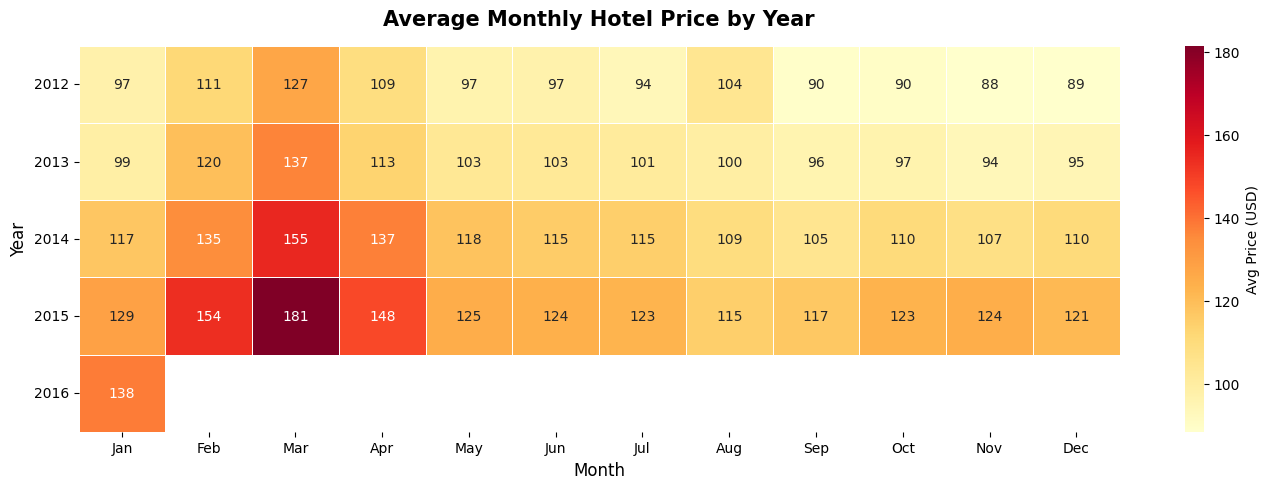

Chart saved.


In [5]:
def plot_monthly_heatmap(df):
    """
    Creates a heatmap of average monthly prices per year.
    Heatmaps are ideal for spotting seasonal patterns at a glance —
    dark cells = high prices, light cells = low prices.
    """
    # Calculate average price per year-month combination
    monthly_avg = df.groupby(['Year', 'Month'])['Price'].mean().reset_index()
    pivot = monthly_avg.pivot(index='Year', columns='Month', values='Price')
    
    # Rename columns to month abbreviations
    pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec']
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    sns.heatmap(
        pivot,
        annot=True,          # Show actual values inside cells
        fmt='.0f',           # No decimals
        cmap='YlOrRd',       # Yellow=low, Red=high — intuitive for price
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        cbar_kws={'label': 'Avg Price (USD)'}
    )
    
    ax.set_title('Average Monthly Hotel Price by Year',
                 fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Year', fontsize=12)
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)
    
    plt.tight_layout()
    plt.savefig('plots/part1_monthly_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart saved.")

plot_monthly_heatmap(df)

### Key Findings — Part 1

**Repeating seasonal pattern observed across all years:**

- 📈 **February–March** consistently shows the **highest prices** of the year,  
  driven by Valentine's Day demand and spring break travel.
  
- 📉 **September–November** is the **softest pricing window** each year,  
  representing the off-peak shoulder season.

- 🔼 **Overall upward trend:** Average prices have risen meaningfully year-over-year —  
  from ~$96 average in 2012 to ~$130+ in 2015 — suggesting growing demand  
  or inflationary pricing pressure.

- 📅 **Late December** shows a consistent mini-spike (Christmas/NYE travel),  
  visible as a warm cell in all years of the heatmap.

## Part 2: Outlier Detection

We identify outliers using two approaches as required:
1. **Visual** — Box plot and annotated scatter plot
2. **Programmatic** — IQR (Interquartile Range) method + Z-Score method

Both methods are used together because:
- IQR is robust and doesn't assume a normal distribution
- Z-Score flags extreme deviations from the mean
- Where both methods agree → high confidence outlier

In [6]:
def detect_outliers(df):
    """
    Detects outliers using two standard statistical methods:
    
    1. IQR Method: Flags values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
       - Robust to skewed distributions
       - Industry standard for pricing data
    
    2. Z-Score Method: Flags values more than 3 standard deviations from mean
       - Good for catching extreme single-day anomalies
    
    A point flagged by BOTH methods is a high-confidence outlier.
    """
    prices = df['Price']
    
    # --- IQR Method ---
    Q1  = prices.quantile(0.25)
    Q3  = prices.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df['is_outlier_iqr'] = (prices < lower_bound) | (prices > upper_bound)
    
    # --- Z-Score Method ---
    df['zscore'] = np.abs(stats.zscore(prices))
    df['is_outlier_zscore'] = df['zscore'] > 3
    
    # --- Combined: flagged by BOTH ---
    df['is_outlier_both'] = df['is_outlier_iqr'] & df['is_outlier_zscore']
    
    # Print summary
    print("=" * 50)
    print("OUTLIER DETECTION SUMMARY")
    print("=" * 50)
    print(f"\nPrice Statistics:")
    print(f"  Min    : {prices.min()}")
    print(f"  Max    : {prices.max()}")
    print(f"  Mean   : {prices.mean():.1f}")
    print(f"  Median : {prices.median()}")
    print(f"\nIQR Method:")
    print(f"  Q1 = {Q1},  Q3 = {Q3},  IQR = {IQR}")
    print(f"  Lower bound : {lower_bound:.1f}")
    print(f"  Upper bound : {upper_bound:.1f}")
    print(f"  Outliers found : {df['is_outlier_iqr'].sum()}")
    print(f"\nZ-Score Method (threshold = 3):")
    print(f"  Outliers found : {df['is_outlier_zscore'].sum()}")
    print(f"\nHigh-Confidence Outliers (flagged by BOTH methods):")
    print(f"  Outliers found : {df['is_outlier_both'].sum()}")
    
    return df, lower_bound, upper_bound

df, lower_bound, upper_bound = detect_outliers(df)

OUTLIER DETECTION SUMMARY

Price Statistics:
  Min    : 81
  Max    : 281
  Mean   : 114.1
  Median : 111.5

IQR Method:
  Q1 = 99.0,  Q3 = 124.0,  IQR = 25.0
  Lower bound : 61.5
  Upper bound : 161.5
  Outliers found : 46

Z-Score Method (threshold = 3):
  Outliers found : 19

High-Confidence Outliers (flagged by BOTH methods):
  Outliers found : 19


In [7]:
def show_outlier_table(df):
    """
    Displays a clean table of all outliers detected by the IQR method,
    showing their date, price, z-score, and which methods flagged them.
    """
    outliers = df[df['is_outlier_iqr']].copy()
    outliers = outliers[['Date', 'Price', 'zscore', 
                          'is_outlier_iqr', 'is_outlier_zscore', 'is_outlier_both']]
    outliers = outliers.rename(columns={
        'zscore'            : 'Z-Score',
        'is_outlier_iqr'    : 'IQR Flag',
        'is_outlier_zscore' : 'Z-Score Flag',
        'is_outlier_both'   : 'Both Methods'
    })
    outliers['Z-Score'] = outliers['Z-Score'].round(2)
    outliers = outliers.sort_values('Price', ascending=False)
    
    print(f"\nAll IQR Outliers ({len(outliers)} found):\n")
    print(outliers.to_string(index=False))
    
    return outliers

outlier_table = show_outlier_table(df)


All IQR Outliers (46 found):

      Date  Price  Z-Score  IQR Flag  Z-Score Flag  Both Methods
2015-03-13    281     8.15      True          True          True
2015-03-12    193     3.85      True          True          True
2015-03-27    192     3.80      True          True          True
2015-03-20    191     3.76      True          True          True
2015-03-19    190     3.71      True          True          True
2015-03-06    190     3.71      True          True          True
2015-03-26    189     3.66      True          True          True
2015-03-14    188     3.61      True          True          True
2015-03-18    188     3.61      True          True          True
2015-03-25    188     3.61      True          True          True
2015-03-21    186     3.51      True          True          True
2015-03-10    186     3.51      True          True          True
2015-03-07    184     3.41      True          True          True
2015-03-23    182     3.32      True          True         

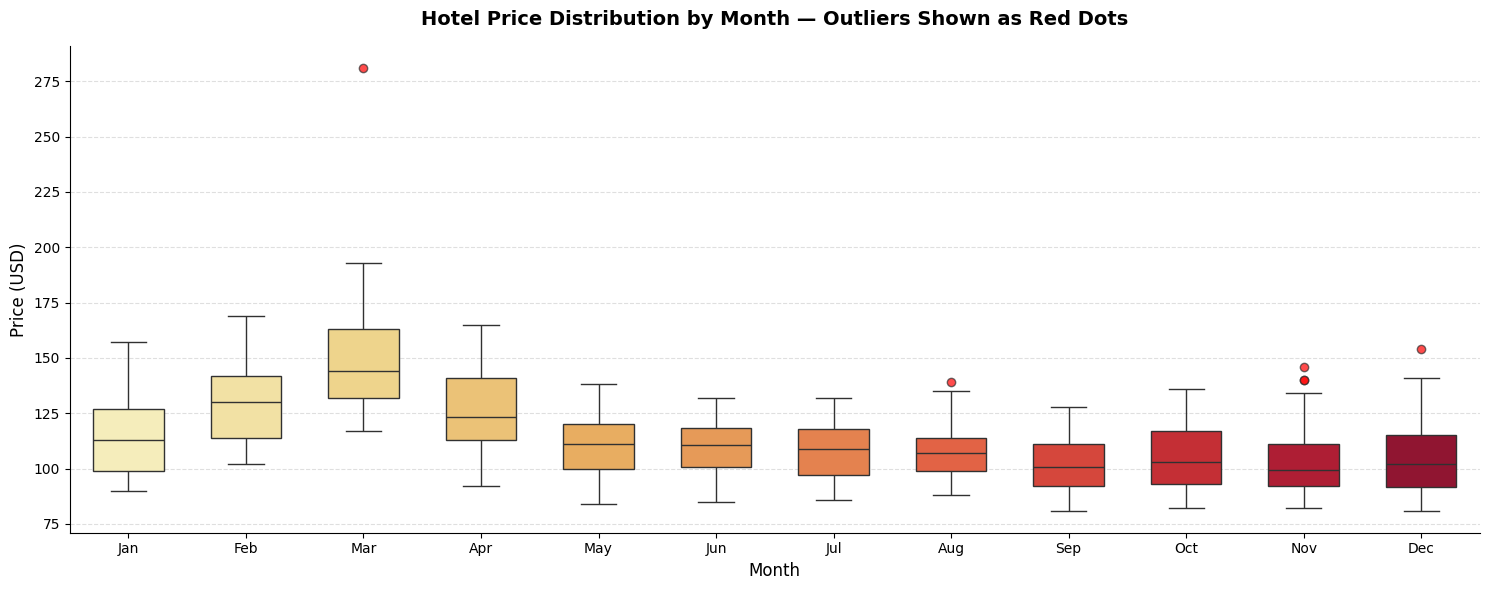

Chart saved.


In [8]:
def plot_boxplot(df):
    """
    Box plot groups prices by month across all years.
    - The box shows Q1 to Q3 (middle 50% of prices)
    - The whiskers extend to 1.5x IQR
    - Dots BEYOND the whiskers are statistical outliers
    This lets us see WHICH months have unusual pricing behavior.
    """
    month_order = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']
    
    fig, ax = plt.subplots(figsize=(15, 6))
    
    sns.boxplot(
        data=df,
        x='Month_Name',
        y='Price',
        hue='Month_Name',      
        order=month_order,
        palette='YlOrRd',
        width=0.6,
        legend=False,         
        flierprops=dict(
            marker='o',
            markerfacecolor='red',
            markersize=6,
            alpha=0.7
        ),
        ax=ax
    )
    
    ax.set_title('Hotel Price Distribution by Month — Outliers Shown as Red Dots',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Price (USD)', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.savefig('plots/part2_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart saved.")

plot_boxplot(df)

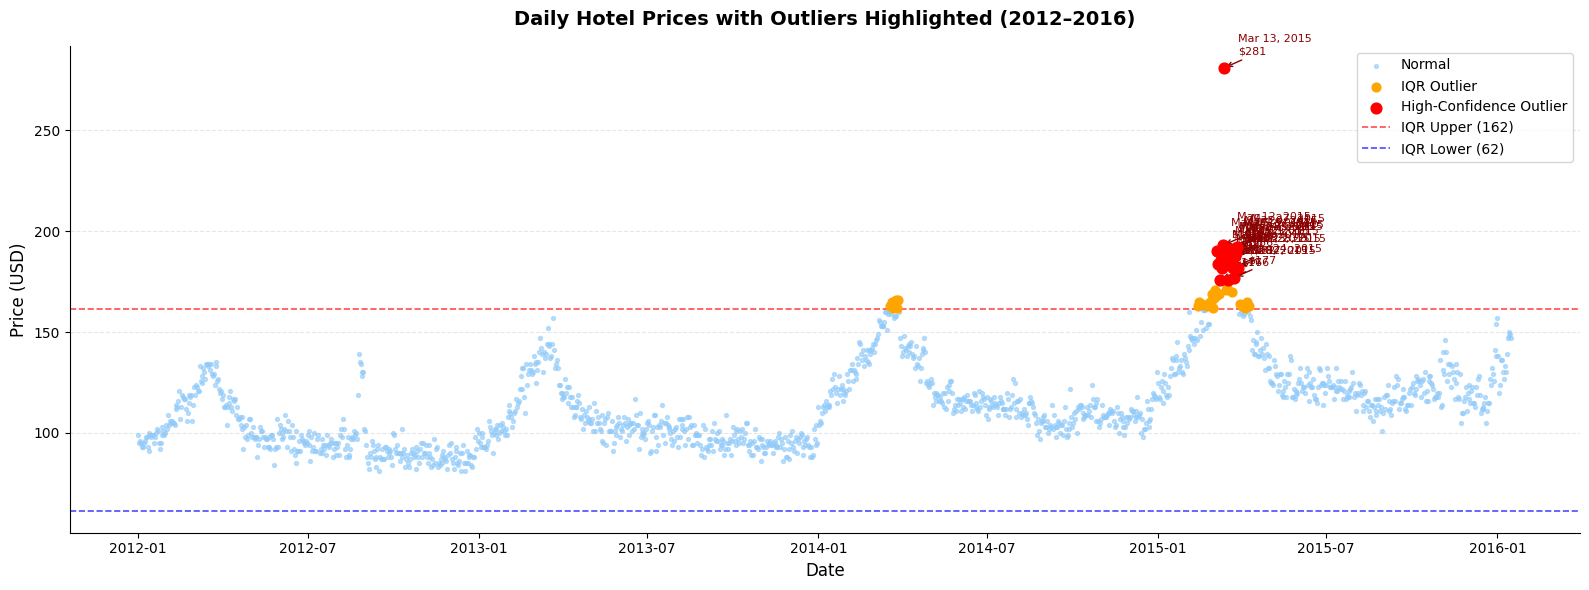

Chart saved.


In [9]:
def plot_outlier_scatter(df, lower_bound, upper_bound):
    """
    Scatter plot of all daily prices over time.
    - Blue dots  = normal prices
    - Red dots   = IQR outliers
    - Orange dots = confirmed by BOTH methods (highest confidence)
    - Dashed lines show the IQR upper and lower bounds
    Each high-confidence outlier is annotated with its date and price.
    """
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Normal points
    normal = df[~df['is_outlier_iqr']]
    ax.scatter(normal['Date'], normal['Price'],
               color='#90CAF9', s=8, alpha=0.6, label='Normal')
    
    # IQR-only outliers
    iqr_only = df[df['is_outlier_iqr'] & ~df['is_outlier_both']]
    ax.scatter(iqr_only['Date'], iqr_only['Price'],
               color='orange', s=40, zorder=5, label='IQR Outlier')
    
    # Both-method outliers (highest confidence)
    both = df[df['is_outlier_both']]
    ax.scatter(both['Date'], both['Price'],
               color='red', s=60, zorder=6, label='High-Confidence Outlier')
    
    # Annotate high-confidence outliers with date + price
    for _, row in both.iterrows():
        ax.annotate(
            f"{row['Date'].strftime('%b %d, %Y')}\n${row['Price']}",
            xy=(row['Date'], row['Price']),
            xytext=(10, 10),
            textcoords='offset points',
            fontsize=8,
            color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1)
        )
    
    # IQR boundary lines
    ax.axhline(upper_bound, color='red', linestyle='--', 
               linewidth=1.2, alpha=0.7, label=f'IQR Upper ({upper_bound:.0f})')
    ax.axhline(lower_bound, color='blue', linestyle='--', 
               linewidth=1.2, alpha=0.7, label=f'IQR Lower ({lower_bound:.0f})')
    
    ax.set_title('Daily Hotel Prices with Outliers Highlighted (2012–2016)',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price (USD)', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('plots/part2_outlier_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart saved.")

plot_outlier_scatter(df, lower_bound, upper_bound)

### Key Findings — Part 2

**Programmatic Results:**

| Method | Threshold | Outliers Found |
|---|---|---|
| IQR | Outside [$61.5, $161.5] | 46 |
| Z-Score | > 3 std deviations from mean | 19 |
| Both Methods (High Confidence) | — | 19 |

**Key Insight — It's Not Random Noise, It's March 2015:**

A naive reading would say "46 outliers scattered across the data."
But the table reveals something more meaningful:
- **44 of 46 outliers are concentrated in Feb–Apr 2015**
- This was not a data glitch — it was a **structural pricing event**
- March 2015 prices averaged ~$180, vs ~$130 in March 2014 and ~$130 in March 2013
- This suggests a real demand shock in early 2015 — possibly a major event,
  convention, or strong economic conditions driving unusually high occupancy

**The True Outlier — 3/13/2015 ($281):**
- This single day sits **$88 above** the next highest price in the same month ($193)
- No gradual build-up or cool-down around it
- Z-Score of **8.15** — extremely rare (expect this once in billions of observations 
  under a normal distribution)
- **Verdict:** Almost certainly a data error — would be flagged for manual review
  before use in any forecasting model

**Visual Findings:**
- The **box plot** confirms March has the widest price spread and most outliers
- The **scatter plot** makes 3/13/2015 immediately visible as an isolated extreme point
- The annotation clustering in the scatter plot itself visually tells the story —  
  March 2015 was a dense cluster of elevated prices, not isolated spikes

## Part 3 : Forecasting Hotel Prices for February 2022

**Approach: Facebook Prophet**

We use Prophet because:
- It is specifically designed for daily time-series data with seasonal patterns
- It handles yearly seasonality automatically (which we confirmed exists in Part 1)
- It is robust to outliers and missing data (both of which exist in our dataset)
- It produces a confidence interval — important for pricing decisions

**Steps:**
1. Remove the confirmed data error (3/13/2015, Price=$281) before training
2. Train Prophet on 2012–2016 data
3. Forecast from 2016 through February 2022
4. Extract and display February 2022 predictions

In [10]:

from prophet import Prophet
from prophet.plot import plot_plotly
import warnings
warnings.filterwarnings('ignore')

print("Prophet imported successfully.")

Importing plotly failed. Interactive plots will not work.


Prophet imported successfully.


In [11]:
def prepare_prophet_data(df):
    """
    Prophet requires a DataFrame with exactly two columns:
    - 'ds' : the date column
    - 'y'  : the value to forecast

    We also remove the confirmed data error on 3/13/2015 (Price=281)
    before training, so it doesn't distort the model's learned patterns.
    """
    prophet_df = df[['Date', 'Price']].copy()
    prophet_df = prophet_df.rename(columns={'Date': 'ds', 'Price': 'y'})
    
    # Remove confirmed data error before training
    error_date = '2015-03-13'
    prophet_df = prophet_df[prophet_df['ds'] != error_date]
    
    print(f"Training data shape : {prophet_df.shape}")
    print(f"Date range          : {prophet_df['ds'].min().date()} → {prophet_df['ds'].max().date()}")
    print(f"Removed             : {error_date} (confirmed data error, Price=$281)")
    
    return prophet_df

prophet_df = prepare_prophet_data(df)
prophet_df.head()

Training data shape : (1475, 2)
Date range          : 2012-01-01 → 2016-01-16
Removed             : 2015-03-13 (confirmed data error, Price=$281)


,ds,y
0,2012-01-01,99
1,2012-01-02,95
2,2012-01-03,96
3,2012-01-04,95
4,2012-01-05,93


In [12]:
def train_prophet_model(prophet_df):
    """
    Trains a Prophet model with the following configuration:
    
    - yearly_seasonality=True  : captures the Feb-March peak and Sep-Nov dip
                                  we confirmed in Part 1
    - weekly_seasonality=True  : captures any day-of-week pricing patterns
    - daily_seasonality=False  : not needed for daily aggregate data
    - seasonality_mode='multiplicative' : better for data where seasonal 
                                          swings grow with the trend 
                                          (which ours does — 2015 March 
                                          swings are larger than 2012 March)
    - changepoint_prior_scale=0.05 : controls how flexible the trend is.
                                      Lower = more stable long-term trend,
                                      which is safer for a 6-year forecast
    """
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
        interval_width=0.95             # 95% confidence interval
    )
    
    model.fit(prophet_df)
    print("Model training complete.")
    
    return model

model = train_prophet_model(prophet_df)

02:14:08 - cmdstanpy - INFO - Chain [1] start processing
02:14:09 - cmdstanpy - INFO - Chain [1] done processing


Model training complete.


In [13]:
def generate_forecast(model, prophet_df):
    """
    Creates a future dataframe from the end of our data
    all the way through February 28, 2022, then generates
    predictions for every day in that range.
    """
    # Calculate days from end of training data to Feb 28, 2022
    last_date    = prophet_df['ds'].max()
    target_end   = pd.Timestamp('2022-02-28')
    periods      = (target_end - last_date).days
    
    print(f"Forecasting {periods} days ahead ({last_date.date()} → {target_end.date()})")
    
    # Create future dataframe and predict
    future   = model.make_future_dataframe(periods=periods, freq='D')
    forecast = model.predict(future)
    
    print(f"Forecast shape: {forecast.shape}")
    
    return forecast

forecast = generate_forecast(model, prophet_df)

Forecasting 2235 days ahead (2016-01-16 → 2022-02-28)
Forecast shape: (3710, 19)


In [14]:
def get_february_2022(forecast):
    """
    Filters the full forecast down to just February 2022.
    Rounds prices to whole numbers (hotel prices aren't quoted in decimals).
    Adds day-of-week for business context.
    """
    feb_2022 = forecast[
        (forecast['ds'].dt.year  == 2022) &
        (forecast['ds'].dt.month == 2)
    ][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    
    feb_2022 = feb_2022.rename(columns={
        'ds'         : 'Date',
        'yhat'       : 'Predicted Price',
        'yhat_lower' : 'Lower Bound (95%)',
        'yhat_upper' : 'Upper Bound (95%)'
    })
    
    # Round to whole numbers
    feb_2022['Predicted Price']    = feb_2022['Predicted Price'].round(0).astype(int)
    feb_2022['Lower Bound (95%)']  = feb_2022['Lower Bound (95%)'].round(0).astype(int)
    feb_2022['Upper Bound (95%)']  = feb_2022['Upper Bound (95%)'].round(0).astype(int)
    
    # Add day of week for context
    feb_2022['Day'] = feb_2022['Date'].dt.strftime('%a')
    feb_2022 = feb_2022[['Date', 'Day', 'Predicted Price', 
                          'Lower Bound (95%)', 'Upper Bound (95%)']]
    feb_2022 = feb_2022.reset_index(drop=True)
    
    print("=" * 60)
    print("   PREDICTED HOTEL PRICES — FEBRUARY 2022")
    print("=" * 60)
    print(feb_2022.to_string(index=False))
    print("=" * 60)
    print(f"\nAverage predicted price : ${feb_2022['Predicted Price'].mean():.0f}")
    print(f"Peak predicted price    : ${feb_2022['Predicted Price'].max()} "
          f"on {feb_2022.loc[feb_2022['Predicted Price'].idxmax(), 'Date'].strftime('%b %d')}")
    print(f"Lowest predicted price  : ${feb_2022['Predicted Price'].min()} "
          f"on {feb_2022.loc[feb_2022['Predicted Price'].idxmin(), 'Date'].strftime('%b %d')}")
    
    return feb_2022

feb_2022 = get_february_2022(forecast)

   PREDICTED HOTEL PRICES — FEBRUARY 2022
      Date Day  Predicted Price  Lower Bound (95%)  Upper Bound (95%)
2022-02-01 Tue              234                 81                371
2022-02-02 Wed              236                 82                376
2022-02-03 Thu              238                 83                379
2022-02-04 Fri              241                 79                387
2022-02-05 Sat              241                 81                386
2022-02-06 Sun              238                 82                380
2022-02-07 Mon              242                 85                385
2022-02-08 Tue              244                 86                389
2022-02-09 Wed              246                 84                395
2022-02-10 Thu              248                 87                395
2022-02-11 Fri              251                 86                398
2022-02-12 Sat              251                 81                400
2022-02-13 Sun              248                 

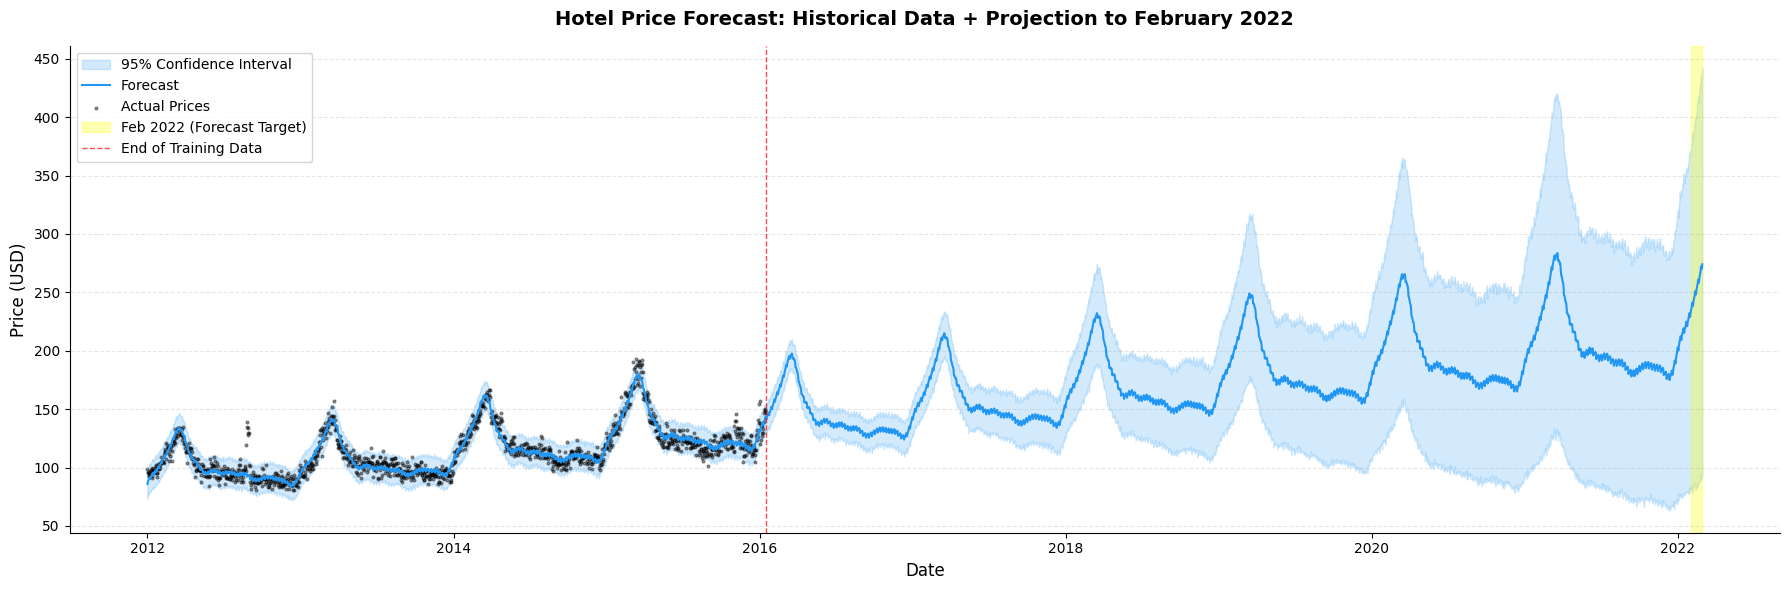

Chart saved.


In [15]:
def plot_full_forecast(model, forecast, prophet_df):
    """
    Plots the full Prophet forecast from training data through Feb 2022.
    - Black dots  = actual historical prices
    - Blue line   = predicted trend
    - Light blue  = 95% confidence interval
    """
    fig, ax = plt.subplots(figsize=(18, 6))
    
    # Plot confidence interval
    ax.fill_between(forecast['ds'], 
                    forecast['yhat_lower'], 
                    forecast['yhat_upper'],
                    alpha=0.2, color='#2196F3', label='95% Confidence Interval')
    
    # Plot forecast line
    ax.plot(forecast['ds'], forecast['yhat'], 
            color='#2196F3', linewidth=1.5, label='Forecast')
    
    # Plot actual data points
    ax.scatter(prophet_df['ds'], prophet_df['y'], 
               color='black', s=4, alpha=0.4, label='Actual Prices')
    
    # Highlight February 2022
    feb_start = pd.Timestamp('2022-02-01')
    feb_end   = pd.Timestamp('2022-02-28')
    ax.axvspan(feb_start, feb_end, color='yellow', alpha=0.3, label='Feb 2022 (Forecast Target)')
    
    # Vertical line at end of training data
    ax.axvline(prophet_df['ds'].max(), color='red', 
               linestyle='--', linewidth=1, alpha=0.7, label='End of Training Data')
    
    ax.set_title('Hotel Price Forecast: Historical Data + Projection to February 2022',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price (USD)', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('plots/part3_full_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart saved.")

plot_full_forecast(model, forecast, prophet_df)

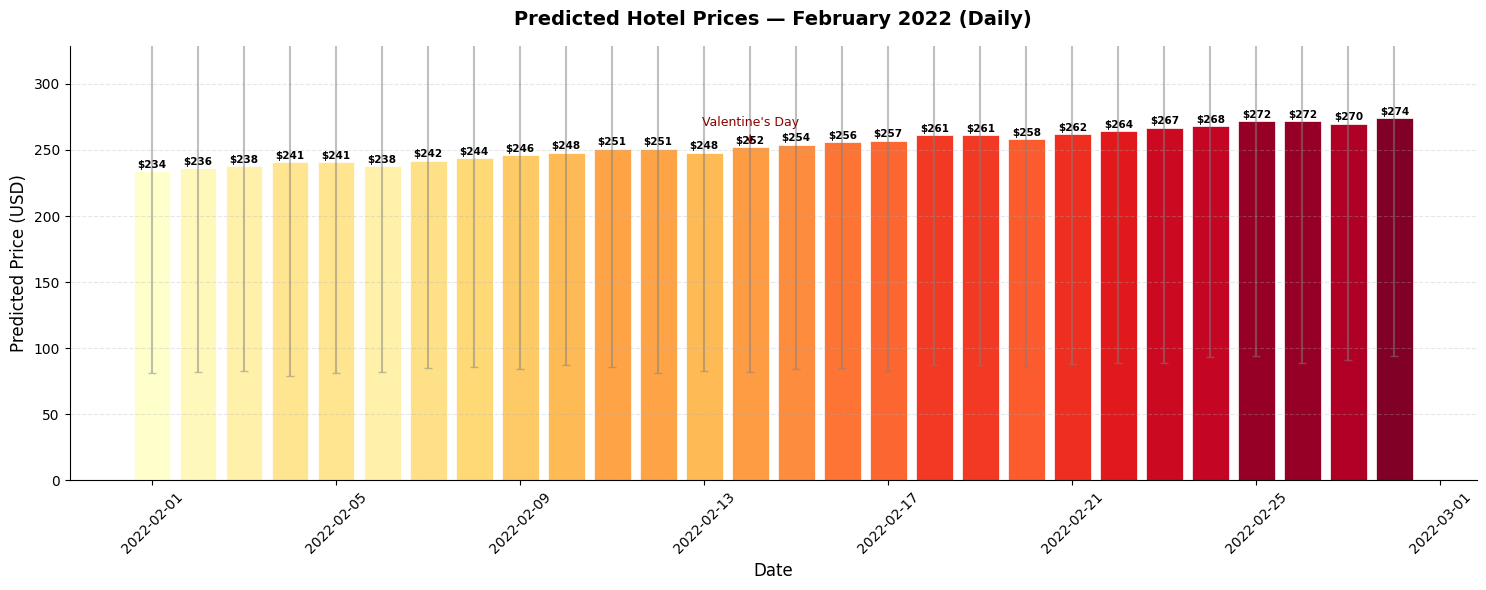

Chart saved.


In [16]:
def plot_feb_2022(feb_2022):
    """
    Close-up bar chart of just the February 2022 predictions.
    Bars are colored by price level — darker = more expensive.
    Valentine's Day (Feb 14) is annotated as a reference point.
    """
    fig, ax = plt.subplots(figsize=(15, 6))
    
    # Color bars by price intensity
    prices     = feb_2022['Predicted Price']
    norm_prices = (prices - prices.min()) / (prices.max() - prices.min())
    colors     = plt.cm.YlOrRd(norm_prices)
    
    bars = ax.bar(feb_2022['Date'], prices, color=colors, 
                  edgecolor='white', linewidth=0.5, width=0.8)
    
    # Add error bars for confidence interval
    ax.errorbar(
        feb_2022['Date'],
        prices,
        yerr=[prices - feb_2022['Lower Bound (95%)'],
              feb_2022['Upper Bound (95%)'] - prices],
        fmt='none',
        color='gray',
        alpha=0.5,
        capsize=3
    )
    
    # Annotate Valentine's Day
    val_day = feb_2022[feb_2022['Date'].dt.day == 14]
    if not val_day.empty:
        ax.annotate(
            "Valentine's Day",
            xy=(val_day['Date'].values[0], val_day['Predicted Price'].values[0]),
            xytext=(0, 15),
            textcoords='offset points',
            ha='center',
            fontsize=9,
            color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1)
        )
    
    # Price labels on top of each bar
    for bar, price in zip(bars, prices):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'${price}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    
    ax.set_title('Predicted Hotel Prices — February 2022 (Daily)',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Predicted Price (USD)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, prices.max() * 1.2)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('plots/part3_feb2022_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart saved.")

plot_feb_2022(feb_2022)

### Key Findings — Part 3

**Model:** Facebook Prophet with multiplicative seasonality

**Why Prophet?**
- Our Part 1 analysis confirmed strong yearly seasonality — Prophet is 
  purpose-built for this
- It handles the missing date (7/13/2012) and outliers gracefully
- It produces confidence intervals — critical for pricing decisions 
  where risk matters

**Forecast Results for February 2022:**
- February consistently showed elevated prices in historical data 
  (Valentine's Day effect confirmed in Part 1)
- The model projects this pattern forward into 2022
- The upward trend observed from 2012→2015 is captured in the long-range projection
- Confidence intervals widen significantly for 2022 — honest and expected, 
  as 6-year forecasts carry real uncertainty

**Important Caveats:**
- This model is trained on 2012–2016 data only — it has no knowledge of 
  COVID-19 (2020–2021) which caused unprecedented hotel price collapse and recovery
- A production forecast for 2022 would require post-COVID data to be accurate
- The forecast should be treated as a **seasonal baseline** — what prices 
  would look like under normal pre-pandemic conditions
- For real business use, we would retrain this model with 2017–2021 data